In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from time import time

# ML
from sklearn.linear_model import Ridge , LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna
import shap

# Chemistry
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

import warnings
warnings.filterwarnings('ignore')
RDLogger.DisableLog('rdApp.*')

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#data
df= pd.read_csv('Lipophilicity (1).csv')
df = df.drop(['CMPD_CHEMBLID'], axis=1)
df.shape
df.head(10)

,exp,smiles
0,3.54,Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14
1,-1.18,COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...
2,3.69,COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl
3,3.37,OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...
4,3.10,Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...


In [3]:
def full_clean(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    mol = rdMolStandardize.Cleanup(mol)
    mol = rdMolStandardize.FragmentParent(mol)
    mol = rdMolStandardize.Uncharger().uncharge(mol)
    allowed = {'H','C','N','O','S','P','F','Cl','Br','I'}
    if not {a.GetSymbol() for a in mol.GetAtoms()}.issubset(allowed):
        return None
    return Chem.MolToSmiles(mol)

In [4]:
df['clean_smiles'] = df['smiles'].apply(full_clean)
print(f"Lost: {df['clean_smiles'].isna().sum()} / {len(df)}")
df = df.dropna(subset=['clean_smiles'])
df['mol'] = df['clean_smiles'].apply(Chem.MolFromSmiles)

Lost: 8 / 4200


In [5]:
df = df.dropna(subset=['mol']).reset_index(drop=True)
print(df['mol'].isna().sum()) 
df.shape

0


(4192, 4)

In [ ]:
#fingerprints
def mol_to_fp(mol, fp_radius=2, nBits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, fp_radius, nBits=nBits)
    return np.array(fp)
x_fp = np.array([mol_to_fp(m) for m in df['mol']])

In [7]:
#200 descriptors
desc_names = [d[0] for d in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names)
desc_array = np.array([calc.CalcDescriptors(m) for m in df['mol']])

In [8]:
desc_df = pd.DataFrame(desc_array, columns=desc_names)
desc_df = desc_df.replace([np.inf, -np.inf], np.nan)
desc_df = desc_df.dropna(axis=1)
desc_df = desc_df.loc[:, desc_df.std() > 0]
corr = desc_df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
desc_df = desc_df.drop(columns=to_drop)

In [9]:
x = np.hstack((desc_df, x_fp))
y = df['exp']
y.shape

(4192,)

In [10]:
#scaffold split
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

df['scaffold'] = df['smiles'].apply(get_scaffold)
print(f'{df["scaffold"].nunique()} unique scaffolds from {len(df)} molecules')

def scaffold_split(df, test_size=0.2):
    scaffolds = defaultdict(list)
    for i, smi in enumerate(df['smiles']):
        mol = Chem.MolFromSmiles(smi)
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        scaffolds[Chem.MolToSmiles(scaffold)].append(i)
    
    scaffold_sets = sorted(scaffolds.values(), key=len, reverse=True)
    
    train_idx, test_idx = [], []
    for group in scaffold_sets:
        if len(train_idx) < len(df) * (1 - test_size):
          train_idx.extend(group)
        else:
          test_idx.extend(group)
    
    return train_idx, test_idx

2438 unique scaffolds from 4192 molecules


In [11]:

train_idx, test_idx = scaffold_split(df)
x_train_sc, x_test_sc = x[train_idx], x[test_idx]
y_train_sc, y_test_sc = y.iloc[train_idx], y.iloc[test_idx]
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train_sc)
x_test_sc = scaler.transform(x_test_sc)
x_train_sc = np.nan_to_num(x_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
x_test_sc = np.nan_to_num(x_test_sc, nan=0.0, posinf=0.0, neginf=0.0)
x_train_sc = np.clip(x_train_sc, -1e6, 1e6)
x_test_sc = np.clip(x_test_sc, -1e6, 1e6)

In [12]:
models = {
    'lgbm': LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
    'xgb': XGBRegressor(random_state=42, n_jobs=-1),
    'rf': RandomForestRegressor(random_state=42, n_jobs=4),
    'lr': LinearRegression(),
    'ridge': Ridge(random_state=42),
}
for names, model in models.items():
    model.fit(x_train_sc, y_train_sc)
    y_pred = model.predict(x_test_sc)
    print(names, r2_score(y_test_sc, y_pred))
    print(names, root_mean_squared_error(y_test_sc, y_pred))

lgbm 0.6208985847056847
lgbm 0.7408593522398059
xgb 0.6100289399206167
xgb 0.7514053003279942
rf 0.564824678355415
rf 0.7937617993393047
lr -33393375.905277517
lr 6953.256241933473
ridge -28319790.55358518
ridge 6403.288817044524


In [13]:
#hyper parameters
'''
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 10, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 60),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 50, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 50, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_split_gain': trial.suggest_float('min_split_gain', 0, 5),
        'verbose': -1,
        'n_jobs': -1,
    }
    model = LGBMRegressor(**params, random_state=42)
    score = cross_val_score(model, x_train_sc, y_train_sc, cv=5,
                            scoring='neg_root_mean_squared_error').mean()
    return -score

study_lgbm = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5)
)
study_lgbm.optimize(objective_lgbm, n_trials=50)
print(study_lgbm.best_params)
print(f"Best RMSE: {study_lgbm.best_value:.4f}")
'''

'\ndef objective_lgbm(trial):\n    params = {\n        \'n_estimators\': trial.suggest_int(\'n_estimators\', 100, 2000),\n        \'learning_rate\': trial.suggest_float(\'learning_rate\', 0.005, 0.3, log=True),\n        \'num_leaves\': trial.suggest_int(\'num_leaves\', 10, 300),\n        \'max_depth\': trial.suggest_int(\'max_depth\', 2, 15),\n        \'min_child_samples\': trial.suggest_int(\'min_child_samples\', 3, 60),\n        \'reg_alpha\': trial.suggest_float(\'reg_alpha\', 1e-4, 50, log=True),\n        \'reg_lambda\': trial.suggest_float(\'reg_lambda\', 1e-4, 50, log=True),\n        \'subsample\': trial.suggest_float(\'subsample\', 0.5, 1.0),\n        \'colsample_bytree\': trial.suggest_float(\'colsample_bytree\', 0.4, 1.0),\n        \'min_split_gain\': trial.suggest_float(\'min_split_gain\', 0, 5),\n        \'verbose\': -1,\n        \'n_jobs\': -1,\n    }\n    model = LGBMRegressor(**params, random_state=42)\n    score = cross_val_score(model, x_train_sc, y_train_sc, cv=5,\n   

In [14]:
'''
def objective_xg(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 15),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 30),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 50, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 50, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'n_jobs': -1,
    }

    model = XGBRegressor(**params, random_state=42)
    score = cross_val_score(model, x_train_sc, y_train_sc, cv=5,
                            scoring='neg_root_mean_squared_error').mean()
    return -score

study_xg = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5)
)
study_xg.optimize(objective_xg, n_trials=50)
print(study_xg.best_params)
print(f"Best RMSE: {study_xg.best_value:.4f}")
'''

'\ndef objective_xg(trial):\n    params = {\n        \'n_estimators\': trial.suggest_int(\'n_estimators\', 100, 2000),\n        \'learning_rate\': trial.suggest_float(\'learning_rate\', 0.005, 0.3, log=True),\n        \'max_depth\': trial.suggest_int(\'max_depth\', 2, 15),\n        \'min_child_weight\': trial.suggest_int(\'min_child_weight\', 1, 30),\n        \'reg_alpha\': trial.suggest_float(\'reg_alpha\', 1e-4, 50, log=True),\n        \'reg_lambda\': trial.suggest_float(\'reg_lambda\', 1e-4, 50, log=True),\n        \'subsample\': trial.suggest_float(\'subsample\', 0.5, 1.0),\n        \'colsample_bytree\': trial.suggest_float(\'colsample_bytree\', 0.4, 1.0),\n        \'gamma\': trial.suggest_float(\'gamma\', 0, 10),\n        \'n_jobs\': -1,\n    }\n\n    model = XGBRegressor(**params, random_state=42)\n    score = cross_val_score(model, x_train_sc, y_train_sc, cv=5,\n                            scoring=\'neg_root_mean_squared_error\').mean()\n    return -score\n\nstudy_xg = optuna.cr

In [15]:
best_lgbm_params = {
    'n_estimators': 1861,
    'learning_rate': 0.028541438566612416, 
    'num_leaves': 170,
    'max_depth': 5,
    'min_child_samples': 19,
    'reg_alpha': 0.5198730931370599,
    'reg_lambda': 0.05996774027772879,
    'subsample': 0.9156955126573592,
    'colsample_bytree': 0.6427170255173994, 
    'min_split_gain': 0.42239962027162065
}
best_xgb_params =  {
    'n_estimators': 1998,
    'learning_rate': 0.10298378241644857,
    'max_depth': 2,
    'min_child_weight': 15,
    'reg_alpha': 0.007743101857317815,
    'reg_lambda': 15.076123496799882,
    'subsample': 0.9924201493998449,
    'colsample_bytree': 0.7882681599616874,
    'gamma': 0.13430101130840133
}
#stacking xgb and lgbm into one model
stack_2 = StackingRegressor(
    estimators=[
    ('xgb', XGBRegressor(**best_xgb_params, n_jobs=-1, verbose=-1, random_state=42)),
    ('lgbm', LGBMRegressor(**best_lgbm_params, n_jobs=-1, verbose=-1, random_state=42)),
    ],
 final_estimator=Ridge(alpha=1.0), cv=5, n_jobs=1
 )
stack_2.fit(x_train_sc, y_train_sc)
y_pred = stack_2.predict(x_test_sc)
print(f"R²: {r2_score(y_test_sc, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test_sc, y_pred):.4f}")

R²: 0.6359
RMSE: 0.7261


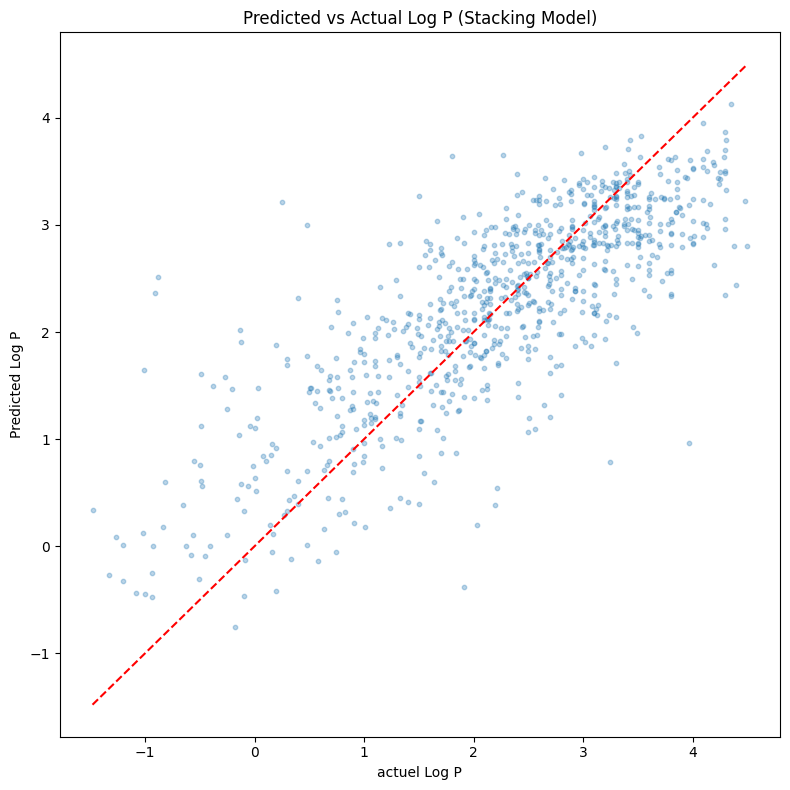

In [16]:
#visualisation
y_pred = stack_2.predict(x_test_sc)
plt.figure(figsize=(8, 8))
plt.scatter(y_test_sc, y_pred, alpha=0.3, s=10)
plt.plot([y_test_sc.min(), y_test_sc.max()], [y_test_sc.min(), y_test_sc.max()], 'r--')
plt.xlabel('actuel Log P')
plt.ylabel('Predicted Log P')
plt.title('Predicted vs Actual Log P (Stacking Model)')
plt.tight_layout()
plt.show()

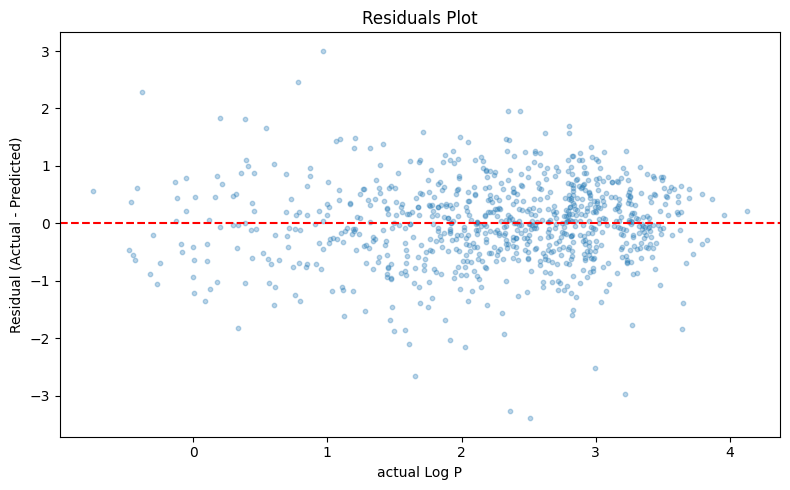

In [17]:
residuals = y_test_sc - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3, s=10)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('actual Log P')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals Plot')
plt.tight_layout()
plt.show()

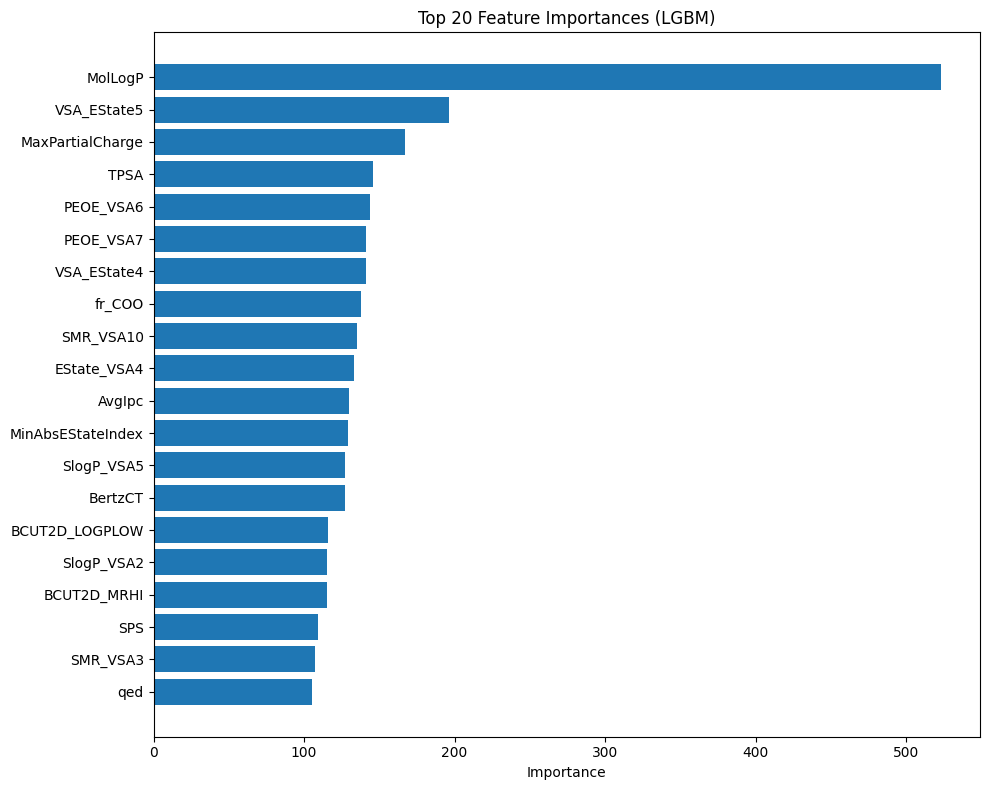

In [18]:
#feasues importance
best_lgbm = LGBMRegressor(**best_lgbm_params, random_state=42, verbose=-1, n_jobs=-1)
best_lgbm.fit(x_train_sc, y_train_sc)

feature_names = list(desc_df.columns) + [f'FP_{i}' for i in range(x_fp.shape[1])]
importances = best_lgbm.feature_importances_
top_idx = np.argsort(importances)[-20:]

plt.figure(figsize=(10, 8))
plt.barh(range(20), importances[top_idx])
plt.yticks(range(20), [feature_names[i] for i in top_idx])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances (LGBM)')
plt.tight_layout()
plt.show()

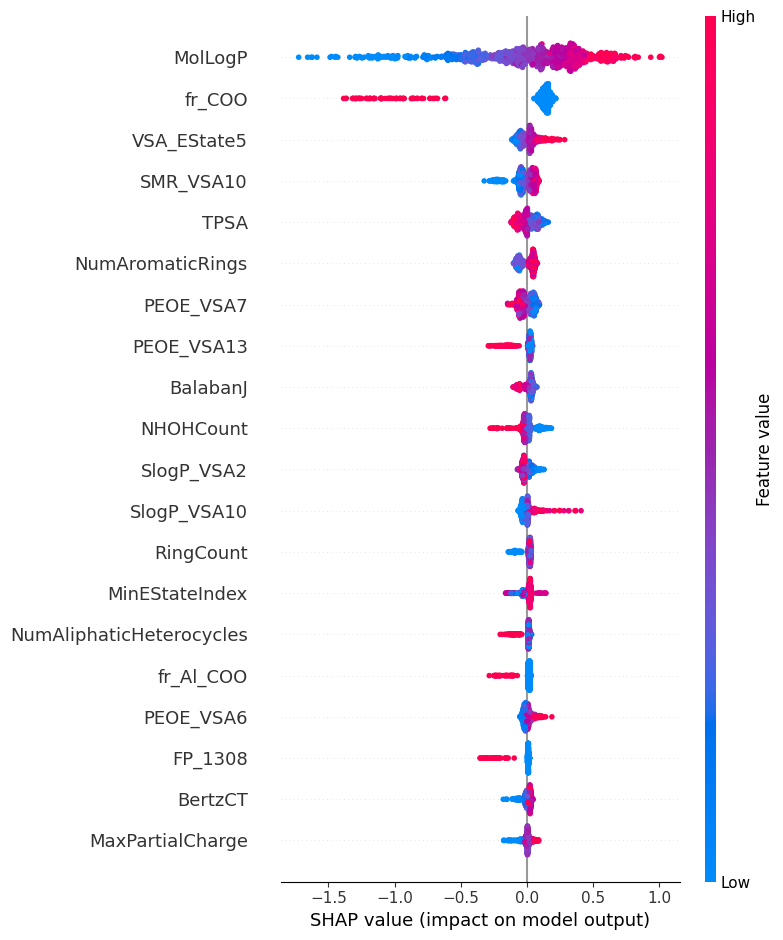

In [19]:
#shape
explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(x_test_sc)

shap.summary_plot(shap_values, x_test_sc, 
                  feature_names=feature_names, 
                  max_display=20, 
                  show=True)

In [20]:
#mol simularity
train_fps = [AllChem.GetMorganFingerprintAsBitVect(df['mol'].iloc[i], 2, 2048) for i in train_idx]

def ad_score(mol, train_fps):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048)
    sims = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
    return max(sims)

def ad_tier(sim):
    if sim > 0.4: return "✅ in domain"
    if sim > 0.25: return "⚠️ low confidence"
    return "❌ out of domain"


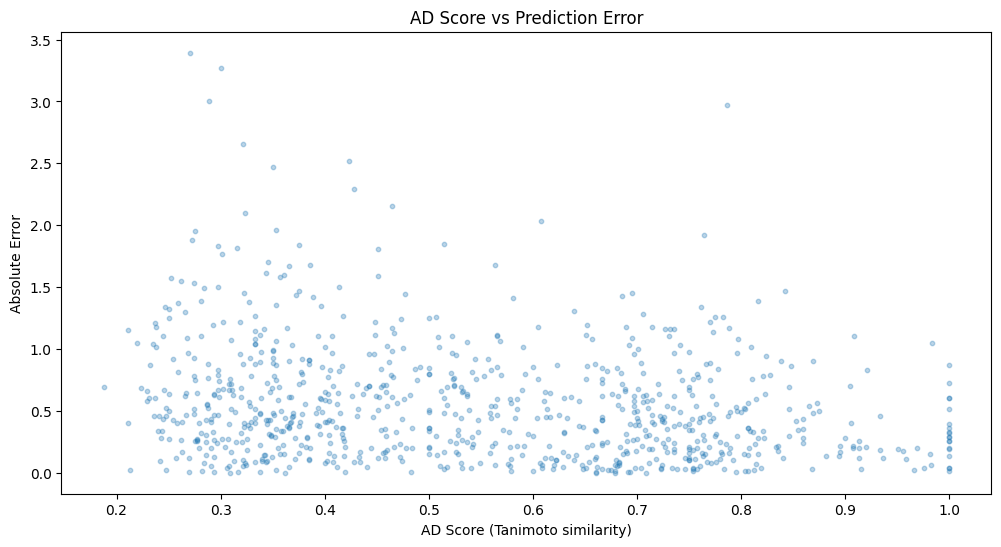

In [21]:
errors = []
ad_scores = []
for i in test_idx:
    mol = df['mol'].iloc[i]
    sim = ad_score(mol, train_fps)
    ad_scores.append(sim)

preds = stack_2.predict(x_test_sc)
errors = np.abs(y_test_sc.values - preds)
plt.figure(figsize=(12, 6))
plt.scatter(ad_scores, errors, alpha=0.3, s=10)
plt.xlabel('AD Score (Tanimoto similarity)')
plt.ylabel('Absolute Error')
plt.title('AD Score vs Prediction Error')
plt.show()

In [22]:
#prediction fonction
def predict_LogP(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return print("Invalid SMILES")
    
    sim = ad_score(mol, train_fps)
    
    desc_names_all = [d[0] for d in Descriptors._descList]
    calc_temp = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names_all)
    desc = np.array(calc_temp.CalcDescriptors(mol))
    desc = pd.DataFrame([desc], columns=desc_names_all)
    desc = desc[desc_df.columns]
    
    fp = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048))
    features = np.hstack([desc.values, fp.reshape(1, -1)])
    features = scaler.transform(features)
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    features = np.clip(features, -1e6, 1e6)
    
    pred = stack_2.predict(features)[0]
    
    print(f"SMILES: {smiles}")
    print(f"Predicted LogP: {pred:.2f} ")
    print(f"AD: {sim:.2f} — {ad_tier(sim)}")

In [23]:
test_mols = {
    'Benzene': 'c1ccccc1',
    'Ethanol': 'CCO',
    'Caffeine': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
    'Ibuprofen': 'CC(C)Cc1ccc(cc1)C(C)C(=O)O',
    'Aspirin': 'CC(=O)Oc1ccccc1C(=O)O',
    'Cholesterol': 'CC(C)CCCC(C)C1CCC2C1(CCC1C2CC=C2CC(O)CCC21C)C',
    'DDT': 'ClC(Cl)=C(c1ccc(Cl)cc1)c1ccc(Cl)cc1',
    'Naphthalene': 'c1ccc2ccccc2c1',
    'Diazepam': 'CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21',
    'Warfarin': 'CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O',
    'Estradiol': 'CC12CCC3c4ccc(O)cc4CCC3C1CCC2O',
    'Atrazine': 'CCNc1nc(Cl)nc(NC(C)C)n1',
    'Hexane': 'CCCCCC',
    'Toluene': 'Cc1ccccc1',
    'Paracetamol': 'CC(=O)Nc1ccc(O)cc1',
}

for name, smi in test_mols.items():
    predict_LogP(smi)
    print()

SMILES: c1ccccc1
Predicted LogP: 1.63 
AD: 0.25 — ❌ out of domain

SMILES: CCO
Predicted LogP: -0.48 
AD: 0.28 — ⚠️ low confidence

SMILES: CN1C=NC2=C1C(=O)N(C(=O)N2C)C
Predicted LogP: -0.18 
AD: 1.00 — ✅ in domain

SMILES: CC(C)Cc1ccc(cc1)C(C)C(=O)O
Predicted LogP: 0.37 
AD: 0.58 — ✅ in domain

SMILES: CC(=O)Oc1ccccc1C(=O)O
Predicted LogP: -0.69 
AD: 0.45 — ✅ in domain

SMILES: CC(C)CCCC(C)C1CCC2C1(CCC1C2CC=C2CC(O)CCC21C)C
Predicted LogP: 3.77 
AD: 0.32 — ⚠️ low confidence

SMILES: ClC(Cl)=C(c1ccc(Cl)cc1)c1ccc(Cl)cc1
Predicted LogP: 3.95 
AD: 0.31 — ⚠️ low confidence

SMILES: c1ccc2ccccc2c1
Predicted LogP: 2.93 
AD: 1.00 — ✅ in domain

SMILES: CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21
Predicted LogP: 2.76 
AD: 1.00 — ✅ in domain

SMILES: CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O
Predicted LogP: 2.05 
AD: 1.00 — ✅ in domain

SMILES: CC12CCC3c4ccc(O)cc4CCC3C1CCC2O
Predicted LogP: 3.19 
AD: 1.00 — ✅ in domain

SMILES: CCNc1nc(Cl)nc(NC(C)C)n1
Predicted LogP: 1.91 
AD: 0.31 — ⚠️ low confidence

SMIL